In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib
import geopandas as gpd
import jenkspy
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import scipy
import prophet
import warnings
warnings.filterwarnings("ignore")
from matplotlib.font_manager import FontProperties
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.optimize import curve_fit
import matplotlib.colors as colors
import mapclassify
from libpysal.weights.contiguity import Queen
from libpysal import examples
import geopandas as gpd
from esda.moran import Moran_Local
from splot.esda import lisa_cluster
from scipy.interpolate import UnivariateSpline
import seaborn as sns

In [2]:
font_path = '/Users/carmen/Library/Fonts/RobotoBold.ttf'
font = FontProperties(fname=font_path)


In [3]:
# data = 'mp'
data = 'fb'

In [4]:
# spatialw = 'knn'
spatialw = 'nonspatial'

In [6]:

df_bias_mp_non = pd.read_csv('/Users/carmen/Documents/github/de-bias/DEBIAS_MX/02.Explain_Bias/Inputs/PH_05/Active_population_bias_nonspatial.csv', encoding="latin1")
df_bias_mp_non = df_bias_mp_non[['Area_code', 'bias']].rename(columns={'bias': 'bias_mp_non'})
df_bias_fb_non = pd.read_csv('/Users/carmen/Documents/github/de-bias/DEBIAS_MX/02.Explain_Bias/Inputs/TTS/Active_population_bias_nonspatial.csv', encoding="latin1")
df_bias_fb_non = df_bias_fb_non[['Area_code', 'bias']].rename(columns={'bias': 'bias_fb_non'})

df_bias = pd.merge(df_bias_mp_non, df_bias_fb_non, how='left', on = 'Area_code')

In [7]:
df_census = pd.read_csv('/Users/carmen/Documents/github/de-bias/DEBIAS_MX/02.Explain_Bias/Inputs/Census_data.csv', encoding="latin1")


In [8]:
df_census = df_census.rename(columns={'Municipality.code': 'Area_code'})

In [9]:
df = pd.merge(df_census, df_bias, how='right', on = 'Area_code')

In [10]:
df = df.dropna().reset_index(drop=True)

In [11]:
df

,Area_code,Municipality,Total_residents,Total_houses,P_female,Mean_age,P_age_00_14,P_age_15_39,P_age_65_more,P_migrants,...,Mean_occupants,P_working,Current_income,P_poverty,P_extreme_poverty,P_vulnerable_income,P_educational_lag,P_lack_quality_living_spaces,bias_mp_non,bias_fb_non
0,1001,Aguascalientes,948990,266778,51.308971,31.192068,25.376455,41.052955,7.166349,0.914689,...,3.525875,79.105111,62433.12,23.7,2.0,10.0,9.4,2.3,0.991886,0.907432
1,1002,Asientos,51536,12542,50.983778,28.267412,31.574656,40.237984,6.465952,0.706714,...,4.074110,76.467761,41022.53,40.1,4.1,6.6,21.7,7.9,0.995789,0.963928
2,1003,Calvillo,58250,15546,50.964807,31.087211,28.721120,37.668986,9.689942,2.253947,...,3.726546,71.690177,48863.53,45.8,4.5,3.8,24.6,5.8,0.995039,0.939365
3,1004,Cosío,17000,3937,51.223529,28.704824,30.488235,40.176471,6.576471,0.700041,...,4.263292,77.814654,42930.31,37.0,3.4,9.9,15.8,9.3,0.996647,0.941588
4,1010,El Llano,20853,5210,49.906488,29.156244,29.968348,39.804335,6.675619,0.950324,...,3.887097,73.835194,37946.55,40.6,4.8,5.4,21.2,8.6,0.997602,0.889033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2067,32052,Villa García,19525,4936,50.693982,29.936236,29.787452,38.212548,7.897567,0.538213,...,3.938718,76.183644,36270.28,33.3,1.8,9.9,14.6,2.6,0.997234,0.955544
2068,32053,Villa González Ortega,13208,3492,52.490915,30.141808,32.412174,34.850091,8.843125,1.060847,...,3.766208,67.735413,35669.73,62.5,7.7,5.4,24.6,3.9,0.995836,0.943519
2069,32054,Villa Hidalgo,19446,4951,51.126196,29.224572,32.746823,36.142409,7.778978,1.065527,...,3.912727,73.582605,30695.18,74.9,9.0,4.3,21.1,3.9,0.998046,0.973568
2070,32055,Villanueva,31558,9045,50.598897,34.500856,25.700342,34.323108,13.566358,2.003868,...,3.464128,72.538918,39508.14,50.6,4.3,8.3,22.4,2.5,0.995500,0.934216


In [26]:
df_correlations = df[df.columns[2:-2]]
df_correlations = df_correlations.drop(range(len(df_correlations)))

df_pvalues = df[df.columns[2:-2]]
df_pvalues = df_pvalues.drop(range(len(df_pvalues)))

In [27]:
df_correlations

,Total_residents,Total_houses,P_female,Mean_age,P_age_00_14,P_age_15_39,P_age_65_more,P_migrants,P_afrodescendants,P_disability,...,P_cell_phone,P_internet,Mean_occupants,P_working,Current_income,P_poverty,P_extreme_poverty,P_vulnerable_income,P_educational_lag,P_lack_quality_living_spaces


In [28]:
df_pvalues

,Total_residents,Total_houses,P_female,Mean_age,P_age_00_14,P_age_15_39,P_age_65_more,P_migrants,P_afrodescendants,P_disability,...,P_cell_phone,P_internet,Mean_occupants,P_working,Current_income,P_poverty,P_extreme_poverty,P_vulnerable_income,P_educational_lag,P_lack_quality_living_spaces


In [29]:
row = 0
for i in range(len(df.columns)-2, len(df.columns)):
    bias = df.columns[i]
    correlations = []
    pvalues = []
    for j in range(2, len(df.columns)-2):
        correlations.append(spearmanr(df[df.columns[j]], df[bias]).statistic)
        pvalues.append(spearmanr(df[df.columns[j]], df[bias]).pvalue)
    df_correlations.loc[row] = correlations
    df_pvalues.loc[row] = pvalues
    row += 1

In [30]:
df_correlations = df_correlations.T
df_pvalues = df_pvalues.T

In [31]:
df_correlations['average'] = df_correlations.mean(axis=1)
df_pvalues['average'] = df_correlations['average']

In [32]:
df_correlations = df_correlations.sort_values(by=['average'])
df_pvalues = df_pvalues.sort_values(by=['average'])

In [33]:
df_correlations = df_correlations.drop(['average'], axis=1)
df_pvalues = df_pvalues.drop(['average'], axis=1)

In [24]:
df_correlations = df_correlations.T

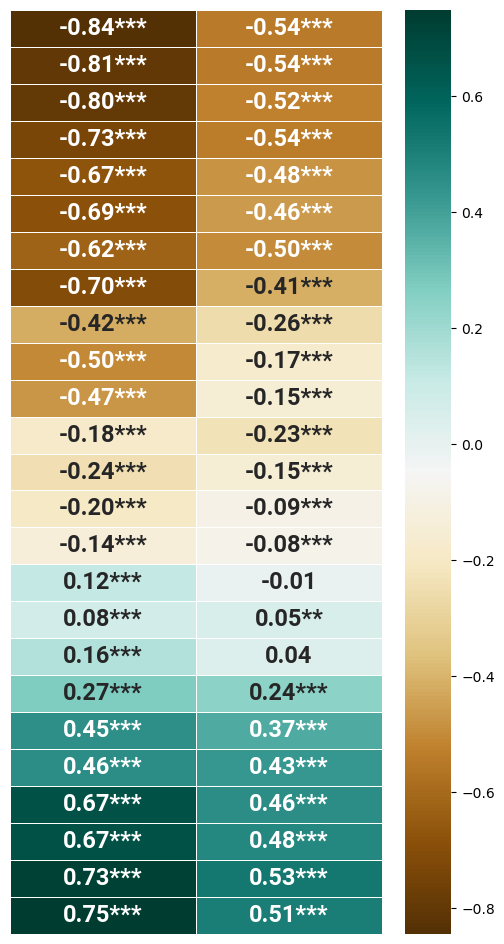

In [49]:
fig, ax = plt.subplots(figsize=(6, 12))

def pvalue_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.1:
        return "*"
    else:
        return ""
    
annot = df_correlations.copy().astype(str)

for i in df_correlations.index:
    for j in df_correlations.columns:
        corr = df_correlations.loc[i, j]
        pval = df_pvalues.loc[i, j]
        annot.loc[i, j] = f"{corr:.2f}{pvalue_stars(pval)}"

sns.heatmap(df_correlations, annot=annot, fmt="", cmap="BrBG", linewidths=0.5, ax=ax, 
            annot_kws={"fontsize": 17, "fontproperties": font})

# ax.tick_params(axis='both', which='both', width=0, length=0, labelsize=18, pad=6)

ax.tick_params(axis="both", which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)
    label.set_fontsize(18)
    

    
plt.savefig('/Users/carmen/Documents/github/de-bias/DEBIAS_MX/manuscript/figures/plots/correlations/correlations_nolabels.pdf', bbox_inches='tight')

plt.show()